# Path-Analysis Charts

## Imports

In [9]:
import pandas as pd

pd.options.mode.chained_assignment = None

## Load data

In [48]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")
# only consider test trials 
test_df = df[df["eprocs"].str.contains("Test")]

test_df["StartEnd"] = test_df["StartAt"] + test_df["EndAt"]

In [49]:
# Compute quartiles for participants
test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

# Compute accuracy for each path
test_df["path_mean_acc"] = test_df.groupby("StartEnd")["accuracy"].transform("mean")

## Test phase

### Path accuracy by quartile
Plot all the trials, order them by % correct, with a histogram (light gray scale). Add to this graph lines or points, colored by quartile (e.g. the top quartile might get 100% on the easy ones, while the bottom might get 60%). In this graph you are looking at how the different quartiles compare, going from easy to difficult. 

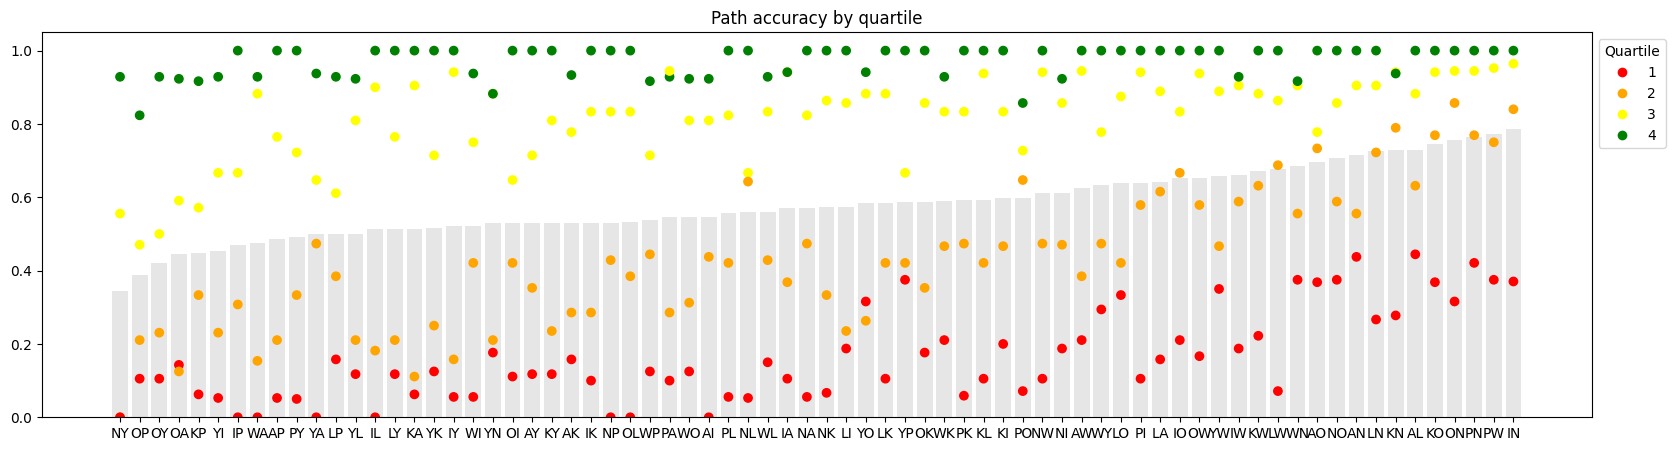

In [80]:
from matplotlib import cm
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(20, 5))

# Plot trial histogram, ordered by % correct, grayscale
path_accs = test_df[["StartEnd", "path_mean_acc"]].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

ax.bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color="0.9")

# Plot accuracies by quartile.
test_df["path_quartile_mean_acc"] = test_df.groupby(["StartEnd", "quartile"], observed=True)["accuracy"].transform("mean")
q_path_accs = test_df[["StartEnd", "quartile", "path_quartile_mean_acc"]].drop_duplicates(subset=["StartEnd", "quartile"], keep="first")

color_dict = {1: "red", 2: "orange", 3: "yellow", 4: "green"}
q_path_accs["color"] = q_path_accs["quartile"].apply(lambda x: color_dict[x])

ax.scatter(q_path_accs["StartEnd"], q_path_accs["path_quartile_mean_acc"], color=q_path_accs["color"])

# Add axis labels, legend, and show plot
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='Quartile', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Path accuracy by quartile")
plt.show()

### Metrics and path accuracies
For the same grayscale background ordering the graphs by overall difficulty, also plot graph metrics of the minimal path (e.g. length, number of turns, etc which are required to complete the minimal path). In this result you are comparing the path with its metrics. 

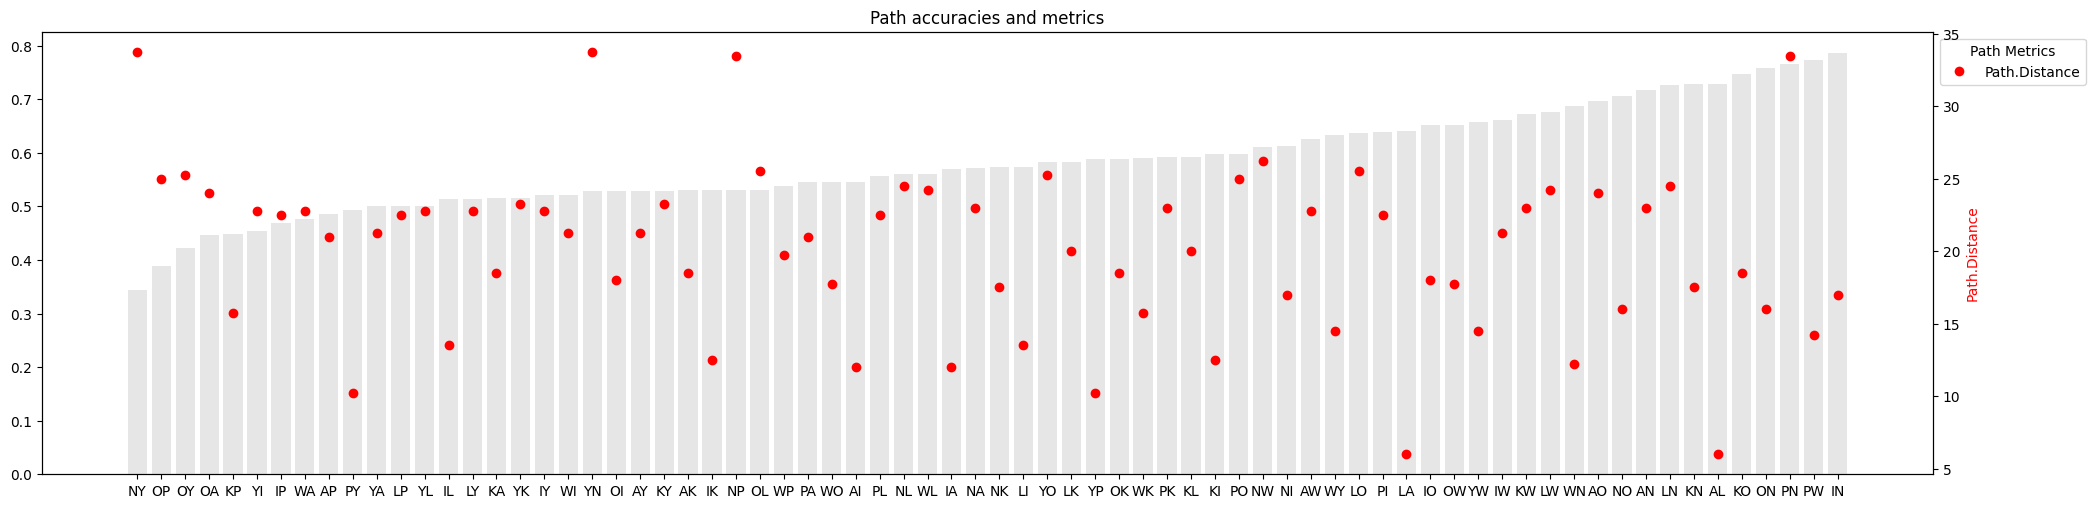

In [85]:
from matplotlib import cm
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(20, 5))

# Plot trial histogram, ordered by % correct, grayscale
path_accs = test_df[["StartEnd", "path_mean_acc", "Path.Distance"]].drop_duplicates(subset=["StartEnd"], keep="first")
path_accs = path_accs.sort_values("path_mean_acc")

ax.bar(path_accs["StartEnd"], path_accs["path_mean_acc"], color="0.9")

# Plot path length.
ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
color = 'red'
ax2.set_ylabel('Path.Distance', color=color)  # we already handled the x-label with ax1
ax2.scatter(path_accs["StartEnd"], path_accs["Path.Distance"], color=color)
# ax2.tick_params(axis='y', labelcolor=color)

# Add axis labels, legend, and show plot
fig.tight_layout() 
color_dict = {"Path.Distance": "red"}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='Path Metrics', handles=handles, bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Path accuracies and metrics")
plt.show()

### TODO
Check whether the minimal path is the most popular path (regardless of whether people got it right or wrong) across all the test paths. Also check if this is true for all quartiles. For the top quartile maybe everyone takes it, while for the bottom quartile, fewer will take it, but it still might be most popular. 

### TODO
You could also superimpose which fraction take the minimal by quartile and overall on the path difficulty grayscale histogram. 

## Learning phase
TODO
For the learning phase:

How often do they go through each node, first and second phase. 

Divide treeb analysis so the number is equal, even if it does not separate to first and second phases. 

How often do they visit each node by quartile, first and second phases.

Correlations between node visits in learning and graph metrics for that node

Do the node visits and treeb metrics in learning correlate with whether the node is part of the minimal and path difficulty in the test phase?

## TODO
You could look at how performance in the trail phase correlated with how the nodes are explore in the learning phase— which might be an interesting differentiator especially for hard paths